# 딥러닝

딥러닝은 층을 깊게 한 심층 신경망   
심층 신경망은 지금까지 설명한 신경망을 바탕으로 뒷단에 층을 추가하기만 하면 만들 수 있지만, 커다한 문제가 몇개 있음   
이번 장에서는 딥러닝의 특징과 과제, 그리고 가능성을 살펴봄   
그리고 오늘날의 첨단 딥러닝에 대한 설명도 있음

## 더 깊게

신경망을 구성하는 다양한 계층과 학습에 효과적인 기술, 영상 분야에 특히 유용한 CNN과 매개변수 최적화 기법 등 그동안 신경망에 대해 많은 것을 배움   
이 모두가 딥러닝에선 중요한 기술   
이번 절에서는 그동안 배운 기술을 집약하고 싴층 신경망을 만들어 MNIST 데이터셋의 손글씨 숫자 인식에 도전해볼 예정   

### 더 깊은 신경망으로

이번 절에서는 아래 그림과 같이 구성된 CNN을 만들고자 함 (이 신경망은 다음 절에서 설명하는 VGG 신경망을 참고함)   
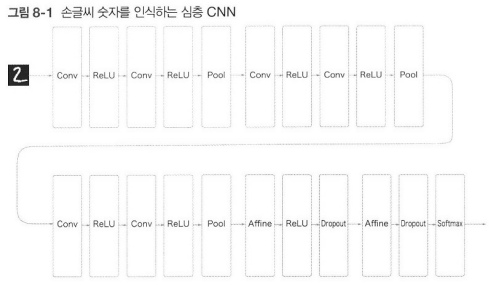   
- 보기에도 지금까지 구현한 신경망보다 층이 깊음   
- 여기에서 사용하는 합성곱 계층은 모두 3 X 3 크기의 작은 필터로, 층이 깊어지면서 채널 수가 더 늘어나는 것이 특징   
- (합성곱 계층의 채널 수는 앞 계층에서부터 순서대로 16, 16, 32, 32, 64, 64로 늘어감)
- 또 그림과 같이 풀링 계층을 추가하여 중간 데이터의 공간 크기를 점차 줄여감
- 그리고 마지막 단의 완전연결 계층에서는 드롭아웃 계층을 사용함   
- 가중치 초기값으로 He 초깃값을 사용하고, 가중치 매개변수 갱신에는 Adam을 이용함   

여기까지 내용을 정리하면 이 신경망의 특징은   
- 3 X 3의 작은 필터를 사용한 합성곱 계층
- 활성화 함수는 ReLU
- 완전연결 계층 뒤에 드롭아웃 계층 사용
- Adam을 사용해 최적화
- 가중치 초깃값은 'He의 초깃값'   

위에서 보듯 이 신경망에는 그동안 배운 신경망 기술이 잔뜩 있음   
그럼 이 신경망을 학습시켜보기   
결과부터 말하면 이 신경망의 정화도는 99.38%가 됨 - 이정도면 아주 훌륭한 성능   

> 이 신경망을 구현한 소스 코드는 책에서 준비해놓음   
> 이 코드들을 사용하여 학습을 직접 시켜보면 아주 오래걸림 (아마 반나절)   
> 이 책에서는 학습된 가중치 매개변수를 준비해놓음   

이 신경망이 잘못 인식할 확률은 겨우 0.62%   
그럼 실제로 어떤 이미지를 인식하지 못했는지 살펴보면, 다음 그림은 인식에 실패한 예시   
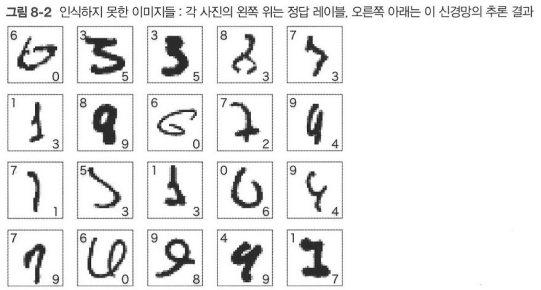   
- 위 그림의 사진들은 우리 인간도 판단하기 어려운 이미지
- 실제로 우리고 똑같이 '인식 오류'를 저지르는 이미지가 여럿 포함되어 있음

이번의 심층 CNN은 정확도가 높고, 잘못 인식한 이미지들도 인간과 비슷한 인식 오류를 저지르고 있음   
이런 점에서도 심층 CNN의 잠재력이 크다는 것을 느낄 수 있음

In [14]:
import sys, os
sys.path.append(os.path.pardir)

import pickle
import numpy as np
from collections import OrderedDict
from codes.layers import *


class DeepConvNet:
    """정확도 99% 이상의 고정밀 합성곱 신경망

    신경망 구성은 아래와 같음
        conv - relu - conv- relu - pool -
        conv - relu - conv- relu - pool -
        conv - relu - conv- relu - pool -
        affine - relu - dropout - affine - dropout - softmax
    """
    def __init__(self, input_dim=(1, 28, 28),
                 conv_param_1 = {'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_2 = {'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_3 = {'filter_num':32, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_4 = {'filter_num':32, 'filter_size':3, 'pad':2, 'stride':1},
                 conv_param_5 = {'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                 conv_param_6 = {'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                 hidden_size=50, output_size=10):
        # 가중치 초기화
        # 각 층의 뉴런 하나당 앞 층의 몇 개 뉴런과 연결되는가（TODO: 자동 계산되게 바꿀 것）
        pre_node_nums = np.array([1*3*3, 16*3*3, 16*3*3, 32*3*3, 32*3*3, 64*3*3, 64*4*4, hidden_size])
        wight_init_scales = np.sqrt(2.0 / pre_node_nums)  # ReLU를 사용할 때의 권장 초깃값
        
        self.params = {}
        pre_channel_num = input_dim[0]
        for idx, conv_param in enumerate([conv_param_1, conv_param_2, conv_param_3, conv_param_4, conv_param_5, conv_param_6]):
            self.params['W' + str(idx+1)] = wight_init_scales[idx] * np.random.randn(conv_param['filter_num'], pre_channel_num, conv_param['filter_size'], conv_param['filter_size'])
            self.params['b' + str(idx+1)] = np.zeros(conv_param['filter_num'])
            pre_channel_num = conv_param['filter_num']
        self.params['W7'] = wight_init_scales[6] * np.random.randn(64*4*4, hidden_size)
        self.params['b7'] = np.zeros(hidden_size)
        self.params['W8'] = wight_init_scales[7] * np.random.randn(hidden_size, output_size)
        self.params['b8'] = np.zeros(output_size)

        # 계층 생성
        self.layers = []
        self.layers.append(Convolution(self.params['W1'], self.params['b1'], 
                           conv_param_1['stride'], conv_param_1['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W2'], self.params['b2'], 
                           conv_param_2['stride'], conv_param_2['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Convolution(self.params['W3'], self.params['b3'], 
                           conv_param_3['stride'], conv_param_3['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W4'], self.params['b4'],
                           conv_param_4['stride'], conv_param_4['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Convolution(self.params['W5'], self.params['b5'],
                           conv_param_5['stride'], conv_param_5['pad']))
        self.layers.append(Relu())
        self.layers.append(Convolution(self.params['W6'], self.params['b6'],
                           conv_param_6['stride'], conv_param_6['pad']))
        self.layers.append(Relu())
        self.layers.append(Pooling(pool_h=2, pool_w=2, stride=2))
        self.layers.append(Affine(self.params['W7'], self.params['b7']))
        self.layers.append(Relu())
        self.layers.append(Dropout(0.5))
        self.layers.append(Affine(self.params['W8'], self.params['b8']))
        self.layers.append(Dropout(0.5))
        
        self.last_layer = SoftmaxWithLoss()

    def predict(self, x, train_flg=False):
        for layer in self.layers:
            if isinstance(layer, Dropout):
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x, train_flg=True)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        acc = 0.0

        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx, train_flg=False)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt)

        return acc / x.shape[0]

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        tmp_layers = self.layers.copy()
        tmp_layers.reverse()
        for layer in tmp_layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        for i, layer_idx in enumerate((0, 2, 5, 7, 10, 12, 15, 18)):
            grads['W' + str(i+1)] = self.layers[layer_idx].dW
            grads['b' + str(i+1)] = self.layers[layer_idx].db

        return grads

    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open( file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, layer_idx in enumerate((0, 2, 5, 7, 10, 12, 15, 18)):
            self.layers[layer_idx].W = self.params['W' + str(i+1)]
            self.layers[layer_idx].b = self.params['b' + str(i+1)]

In [5]:
import sys, os
sys.path.append(os.path.join(os.path.pardir))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from codes.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

network = DeepConvNet()  
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=20, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr':0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# 매개변수 보관
network.save_params("deep_convnet_params.pkl")
print("Saved Network Parameters!")

train loss:2.390596723579327
=== epoch:1, train acc:0.077, test acc:0.098 ===
train loss:2.3399862904586985
train loss:2.325095958086553
train loss:2.271968855274082
train loss:2.308849751771821
train loss:2.2864539349026543
train loss:2.2478944258882168
train loss:2.2958246129089774
train loss:2.2963697881211713
train loss:2.281486191852051
train loss:2.303506482509883
train loss:2.2717008570129247
train loss:2.2124406560105943
train loss:2.2867763270086425
train loss:2.2383621001550598
train loss:2.24793807528882
train loss:2.2110026542689245
train loss:2.204911769389868
train loss:2.226694473032629
train loss:2.1814126776089626
train loss:2.2243722105693577
train loss:2.212638164093867
train loss:2.1601962321279053
train loss:2.15219345930852
train loss:2.1379719263851142
train loss:2.168961347770113
train loss:2.1392845178204998
train loss:2.0624000693461313
train loss:2.139655427975687
train loss:2.095229320406362
train loss:2.1481814510178494
train loss:1.9832201795618776
train l

### 정확도를 더 높이려면

<What is the class of this image?> 웹 사이트는 다양한 데이터셋을 대상으로 그동안 논문 등에서 발표한 기법들의 정확도 순위를 정리해둠   
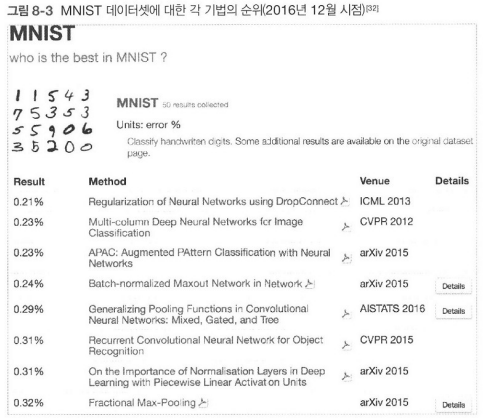   
- 그림의 순위를 보면 'Neural Networks'나 'Deep', 'Convolutional'이라는 키워드가 돋보임   
- 사실 상위권은 대부분 CNN을 기초로 한 기법들이 점령했음   
- 참고로 2016년 10월 기준 MNIST 데이터셋에 대한 정확도 1위는 99.79%(오류율 0.21%)이며, 이 기법도 CNN을 기초로 함
- 다만 이 목록의 기법들이 사용하는 CNN들은 그다지 깊지 않음 (합성곱 계층 2개에 완전연결 계층 2개 정도인 신경망)   

> MNIST 데이터셋에 대해서는 층을 아주 깊게 하지 않고도 (책 당시에는) 최고 수준의 결과가 나옴   
> 이는 손글씨 숫자라는 문제가 비교적 단순해서 신경망의 표현력을 극한까지 높일 필요가 없기 때문   
> 그래서 층을 싶게 해도 혜택이 적다고 할 수 있음   
> 반면, 나중에 소개하는 대규모 일반 사물 인식에서는 문제가 훨씬 복잡해지므로 층을 깊게 하면 정확도를 크게 끌어올릴 수 있음   

위 그림의 상위 기법들을 참고하면 정확도를 더 높일 수 있는 기술이나 힌트를 발견할 수 있음   
- 예를 들어 앙상블 학습, 학습률 감소, 데이터 확장 등이 정확도 향상에 공헌하고 있음   
- 특히 데이터 확장은 손쉬운 방법이면서도 정확도 개선에 아주 효과적임   

**데이터 확장(data augmentation)** 은 입력 이미지(훈련 이미지)를 알고리즘을 동원해 '인위적'으로 확장함   
아래 그림과 같이 입력 이미지를 회전하거나 세로로 이동하는 등 미세한 변화를 주어 이미지의 개수를 늘리는 것 - 이는 데이터가 몇 개 없을 때 특히 효과적인 수단   
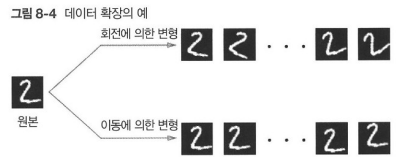   
- 데이터 확장은 위 그림과 같은 변형 외에도 다양한 방법으로 이미지를 확장할 수 있음   
- 예를 들어 이미지 일부를 잘라내는 **crop** 이나 좌우를 뒤집는 **flip** 등이 있음   
- 일반적인 이미지에는 밝기 등의 외형 변화나 확대, 축소 등의 스케일 변화도 효과적
- 어쨌든 데이터 확장을 동원해 훈련 이미지의 개수를 늘릴 수 있다면 딥러닝의 인식 수준을 개선할 수 있음
- 이것은 쉬운 '트릭'이라 가볍게 생각할 수 있지만, 멋진 결과를 가져오는 경우가 많음

이 책에서는 데이터 확장은 구현하지 않지만, 보다시피 어렵지 않은 방식이니 도전해보기 좋음

### 깊게 하는 이유

'층을 깊게 하는 것'이 왜 중요한가에 대한 이론적인 근거는 아직 많이 부족한 것이 사실   
그래도 지금까지의 연구와 실험 결과를 바탕으로 설명할 수 있는 것은 몇 가지 있음 (다소 직관적이긴 하지만)   
이번 절에서는 **'층을 깊게 하는 것'의 중요성** 에 대해서, 이를 뒷받침하는 데이터와 설명을 몇 가지 소개함   

우선 층을 깊게 하는 것의 중요성은 ILSVRC로 대표되는 대규모 이미지 인식 대회의 결과에서 파악할 수 있음   
이 대회에서 상위를 차지한 기법 대부분은 딥러닝 기반이며, 그 경향은 신경망을 더 깊게 만드는 방향으로 가고 있음   
층의 깊이에 비례해 정확도가 좋아지는 것   

이어서 층을 깊게 할 때의 이점을 설명   
그 이점 하나는 신경망의 매개변수 수가 줄어든다는 것   
층을 깊게 한 신경망은 깊지 않은 경우보다 적은 매개변수로 같은 (혹은 그 이상) 수준의 표현력을 달성할 수 있음   
합성곱 연산에서의 필터 크기에 주목해 생각해 보면 쉽게 이해됨   
- 예를 하나 보면, 아래 그림은 5 X 5 필터로 구성된 합성곱 계층   
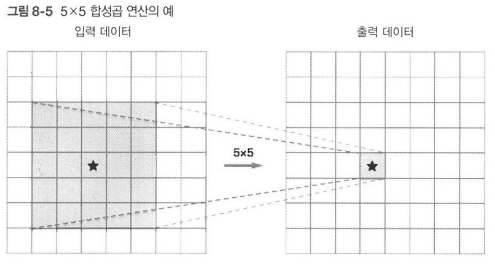   
- 여기에서 주목할 점은 출력 데이터의 각 노드가 입력 데이터의 어느 영역으로부터 계산되었느냐는 것   
- 당연하지만 그림의 예에서는 각각의 출력 노드는 입력 데이터의 5 X 5 크기 영역에서 계산됨   

이어서 아래 그림처럼 3 X 3의 합성곱 연산을 2회 반복하는 경우를 생각해보면   
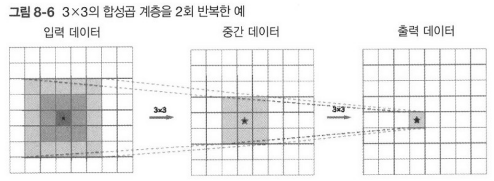   
- 이 경우 출력 노드 하나는 중간 데이터의 3 X 3 영역에서 계산됨   
- 중간 데이터의 3 X 3 영역은 그전 입력 데이터의 5 X 5 크기의 영역에서 계산되어 나옴   
- 즉, 그림의 출력 데이터는 입력 데이터의 5 X 5 영역을 '보고' 계산하게 됨   

5 X 5의 합성곱 연산 1회는 3 X 3의 합성곱 연산을 2회 수행하여 대체할 수 있음   
게다가 전자의 매개변수 수가 25개(5X5)인 반면, 후자는 총 18개(2X3X3)이며, 매개변수 수는 층을 반복할수록 적어짐   
그리고 그 개수의 차이는 층이 깊어질수록 커짐   
- 예를 들어 3 X 3의 합성곱 연산을 3회 반복하면 매개변수는 모두 27개가 되지만,
- 같은 크기의 영역을 1회의 합성곱 연산으로 '보기'위해서는 7 X 7 크기의 필터, 즉 매개변수 49개가 필요함   

> 작은 필터를 겹쳐 신경망을 깊게 할 때의 장점은 매개변수 수를 줄여 넓은 **수용 영역(receptive field)** 을 소화할 수 있다는 데 있음   
> (수용 영역은 뉴런에 변화를 일으키는 국소적인 공간 영역)   
> 게다가 층을 거듭하면서 ReLU 등의 활성화 함수를 합성곱 계층 사이에 끼움으로써 신경망의 표현력이 개선됨   
> 이는 활성화 함수가 신경망에 '비선형' 힘을 가하고, 비선형 함수가 겹치면서 더 복잡한 것도 표현할 수 있게 되기 때문   

학습의 효율성도 층을 깊게 하는 것의 이점   
층을 깊게 함으로써 학습 데이터의 양을 줄여 학습을 고속으로 수행할 수 있다는 뜻   
- 이를 (직감적으로 이해하려면) 이전의 "CNN 시각화하기"에서의 설명을 생각하면 좋음   
- 그때 설명할 때 CNN의 합성곱 계층이 정보를 계층적으로 추출하고 있음을 설명했음
- 앞단의 합성곱 계층에서는 에지 등의 단순한 패턴에 뉴런이 반응하고 층이 깊어지면서 텍스처와 사물의 일부와 점차 더 복잡한 것에 반응한다고 설명함   

그런 네트워크 계층 구조를 기억해두고, '개'를 인식하는 문제를 생각해보면   
- 이 문제를 얕은 신경망에서 해결하려면 합성곱 계층은 개의 특징 대부분을 한 번에 '이해'해야 함   
- 견종도 다양하고 어느 각도에서 찍은 사진이냐 따라 완전히 다르게 보일 수 있음   
- 그래서 개의 특징을 이해하려면 변화가 풍부하고 많은 학습 데이터가 필요하고, 결과적으로 학습 시간이 오래 걸림   

그러나 신경망을 깊게 하면 학습해야 할 문제를 계층적으로 분해할 수 있음   
각 층이 학습해야 할 문제를 더 단순한 문제로 대체할 수 있는 것   
- 예를 들어 처음 층은 에지 학습에 전념하여 적은 학습 데이터로 효율적으로 학습할 수 있음
- 개가 등장하는 이미지보다 에지를 포함한 이미지는 많고, 에지의 패턴은 개라는 패턴보다 구조가 훨씬 간단하기 때문   

또, 층을 깊게 하면 정보를 계층적으로 전달할 수 있다는 점도 중요   
- 예를 들어 에지를 추출한 층의 다음 층은 에지 정보를 쓸 수 있고, 더 고도의 패턴을 효과적으로 학습하리라 기대할 수 있음   
- 즉, 층을 깊이 함으로써 각 층이 학습해야 할 문제를 '풀기 쉬운 단순한 문제'로 분해할 수 있어 효율적으로 학습하리라 기대할 수 있음   

여기까지가 층을 깊게 하는 것이 왜 중요한가에 대한 보충 설명   
단, 최근 일어나고 있는 층의 심화는 층이 깊어도 제대로 학습할 수 있도록 해주는 새로운 기술과 환경(빅데이터와 컴퓨터 연산 능력 등)이 뒷받침되어 나타난 현상임을 강조하고자 함

## 딥러닝의 초기 역사

딥러닝이 지금처럼 큰 주목을 받게 된 계기는 이미지 인식 기술을 겨루는 장인 ILSVGRC(ImageNet Large Scale Visual Recognition Challenge)의 2012년 대회   
그해의 대회에서 딥러닝에 기초한 기법, 일명 AlexNet이 압도적인 성적으로 우승하면서 그동안의 이미지 인식에 대한 접근법을 뿌리부터 뒤흔들었음   
이 2012년 딥러닝의 역습이 전환점이 되어, 그 후로는 대회의 주역은 항상 딥러닝이었음   
이번 절에서는 ILSVRC 대회를 축으로 딥러닝 트렌드를 살펴봄   

### 이미지넷

**이미지넷(ImageNet)** 은 100만 장이 넘는 이미지를 담고 있는 데이터셋   
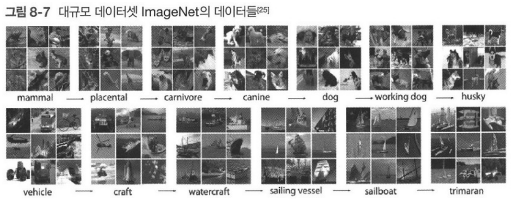   
- 그림과 같이 다양한 종류의 이미지를 포함하며 각 이미지에는 레이블(클래스 이름)이 붙어 있음   
- 매년 열리는 ILSVRC는 이 거대한 데이터셋을 사용하여 자웅을 겨루는 천하제일 이미지 인식 기술 대회인 셈   
- ILSVRC 대회에는 시험 항목이 몇 가지 있는데, 그중 하나가 **분류(Classification)**   
- 분류 부문에서는 1,000개의 클래스를 제대로 분류하는지를 겨룸   
- 그 당시 ILSVRC의 분류 시험 결과를 살펴보면   
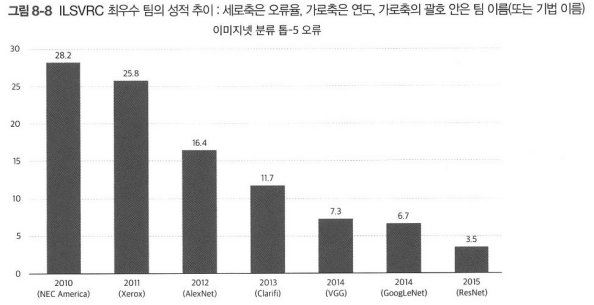   
- 위 그림은 2010년부터 2015년까지 ILSVRC의 분류 부분 우승팀의 성적   
- 여기에서는 **톱-5 오류(top-5 error)** 를 막대 그래프로 나타냄   
- 톱-5 오류란 확률이 가장 높다고 생각하는 후보 클래스 5개 안에 정답이 포함되지 않은, 즉 5개 모두가 틀린 비율   
- 위 그림에서 주목할 점은 2012년 이후 선두는 항상 딥러닝 방식이라는 것   
- 실제로 2012년의 AlexNet이 오류율을 크게 낮췄고, 그 후 딥러닝을 활용한 기법이 꾸준히 정확도를 개선해왔음   
- 특히 2015년에는 150층이 넘는 심층 신경망인 ResNet이 오류율을 3.5%까지 낮췄음 - 이 결과는 일반적인 인간의 인식 능력을 넘어섰다고 함   

그 당시 몇 년간 빼어난 성적을 거둔 딥러닝 중에서도 VGG, GoogLeNet, ResNet은 특히 유명하며, 다양한 딥러닝 분야에서 활용됨   
이어지는 절들에서는 이 세 가지 유명 신경망을 간단히 소개함

### VGG

VGG는 합성곱 계층과 풀링 계층으로 구성되는 '기본적'인 CNN   
다만 아래 그림과 같이 비중 있는 층(합성곱 계층, 완전연결 계층)을 모두 16층(혹은 19층)으로 심화한 게 특징(층의 깊이에 따라서 'VGG16'과 'VGG19'로 구분하기도 함)   
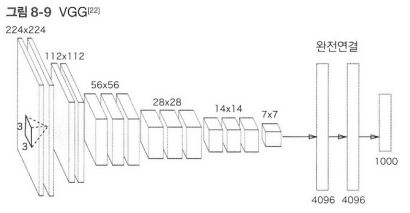   
- VGG에서 주목할 점은 3 X 3.의 작은 필터를 사용한 합성곱 계층을 연속으로 거친다는 것   
- 그림에서 보듯 합성곱 계층을 2~4회 연속으로 풀링 계층을 두어 크기를 절반으로 줄이는 처리를 반복함   
- 그리고 마지막에는 완전연결 계층을 통과시켜 결과를 출력함   

> VGG는 2014년 대회에서 2위에 올랐음   
> 성능 면에서는 1위인 GoogLeNet에 뒤지지만, VGG는 구성이 간단하여 응용하기 좋음   
> 그래서 많은 기술자가 VGG 기반의 신경망을 즐겨 사용함

### GoogLeNet

GoogLeNet의 구성은 아래 그림과 같음   
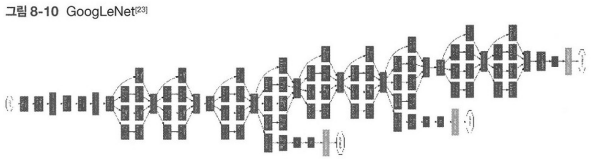   
- 그림의 사각형이 합성곱 계층과 풀링 계층 등의 계층을 나타냄   
- 그림을 보면 구성이 매우 복잡해 보이는데, 기본적으로는 지금까지 보아온 CNN과 다르지 않음   
- 단, GoogLeNet은 세로 방향 깊이뿐 아니라 가로 방향도 깊다는 점이 특징   

GoooLeNet에는 가로 방향에 '폭'이 있음   
이를 인셉션 구조라 하며, 그 기반 구조는 아래 그림과 같음   
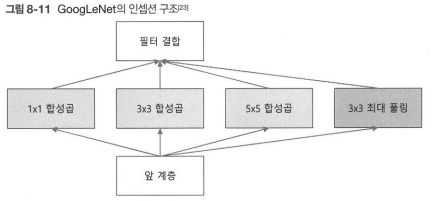   
- 인셉션 구조는 그림과 같이 크기가 다른 필터(와 풀링)를 여러 개 적용하여 그 결과를 결합함   
- 이 인셉션 구조를 하나의 빌딩 블록(구성요소)으로 사용하는 것이 GoogLeNet의 특징
- 또 GoogLeNet에서는 1 X 1 크기의 필터를 사용한 합성곱 계층을 많은 곳에서 사용함   
- 이 1 X 1의 합성곱 연산은 채널 쪽으로 크기를 줄이는 것으로, 매개변수 제거와 고속 처리에 기여함(자세한 것은 원논문을 참고)

### ResNet

**ResNet(Residual Network)** 은 마이크로소프트의 팀이 개발한 네트워크   
그 특징은 지금까지보다 층을 더 깊게 할 수 있는 특별한 '장치'에 있음   

지금까지 층을 깊게 하는 것이 성능 향상에 중요하다는 건 알고 있음   
그러나 딥러닝의 학습에서는 층이 지나치게 깊으면 학습이 잘 되지 않고, 오히려 성능이 떨어지는 경우도 많음   
ResNet에서는 그런 문제를 해결하기 위해서 **스킵 연결(skip connection)** 을 도입합   
이 구조가 층의 깊이에 비례해 성능을 향상시킬 수 있게 한 핵심(물론 층을 깊게 하는 데는 여전히 한계가 있음)   

스킵 연결이란 아래 그림과 같이 입력 데이터를 합성곱 계층을 건너뛰어 출력에 바로 더하는 구조를 말함   
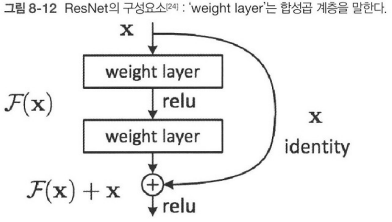   
- 그림에서는 입력 x를 연속한 두 합성곱 계층을 건너뛰어 출력에 바로 연결함
- 이 단축 경로가 없었다면 두 합성곱 계층의 출력이 F(x)가 되나, 스킵 연결로 인해 F(x) + x가 되는 게 핵심   
- 스킵 연결은 층이 깊어져도 학습을 효율적으로 할 수 있도록 해주는데, 이는 역전파 때 스킵 연결이 신호 감쇠를 막아주기 때문   

> 스킵 연결은 입력 데이터를 '그대로' 흘리는 것으로, 역전파 때도 상류의 기울기를 그대로 하류로 보냄   
> 여기에서의 핵심은 상류의 기울기에 아무런 수정도 가하지 않고 '그대로' 흘린다는 것   
> 그래서 스킵 연결로 기울기가 작아지거나 지나치게 커질 걱정 없이 각 층에 '의미 있는 기울기'가 전해지리라 기대할 수 있음   
> 층을 깊게 할수록 기울기가 작아지는 소실 문제를 이 스킵 연결이 줄여주는 것   

ResNet은 앞의 VGG 신경망을 기반으로 스킵 연결을 도입하여 층을 깊게 했음   
그 결과는 아래 그림과 같음   
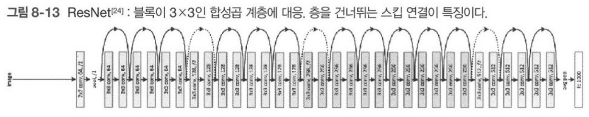   
- 그림과 같이 ResNet은 합성곱 계층을 2개 층마다 건너뛰면서 층을 깊게 함   
- 실험 결과 150층 이상으로 해도 정확도가 오르는 모습을 확인할 수 있음   
- 그리고 ILSVRC 대회에서는 톱-5 오류율이 겨우 3.5%라는 경이적인 결과를 냈음   

> 이미지넷이 제공하는 거대한 데이터셋으로 학습한 가중치 값들은 실제 제품에 활용해도 효과적이고, 또 많이들 그렇게 이용하고 있음   
> 이를 **전이 학습(transfer learning)** 이라고 해서, 학습된 가중치(혹은 그 일부)를 다른 신경망에 복사한 다음, 그 상태로 재학습을 수행함   
> 예를 들어 VGG와 구성이 같은 신경망을 준비하고, 미리 학습된 가중치를 초깃값으로 설정한 후, 새로운 데이터셋을 대상으로 재학습(fine tuning)을 수행함   
> 전이 학습은 보유한 데이터셋이 적을 때 특히 유용한 방법

## 더 빠르게(딥러닝 고속화)

빅데이터와 네트워크의 발전으로 딥러닝에서는 대량의 연산을 수행해야 함   
과거에는 주로 CPU가 계산을 담당했으나, CPU만으로 딥러닝을 처리하기는 부족한 게 현실   
실제로 주위를 둘러보면 딥러닝 프레임워크 대부분은 **GPU(Graphics Processing Unit)** 를 활용해 대량의 연산을 고속으로 처리할 수 있음   
당시 프레임워크에서는 학습을 복수의 GPU와 여러 기기로 분산 수행하기 시작했음   
이번 절에서는 딥러닝 고속화에 관해 이야기해보려 함(참고로, 책에서는 딥러닝 구현을 8.1절에서 마무리하고, GPU 대응 등 여기에서 설명하는 고속화는 적용하지 않음)

### 풀어야 할 숙제

딥러닝의 고속화 얘기를 시작하기에 앞서, 딥러닝에서는 어떠한 처리에 시간이 소요되는지를 보면   
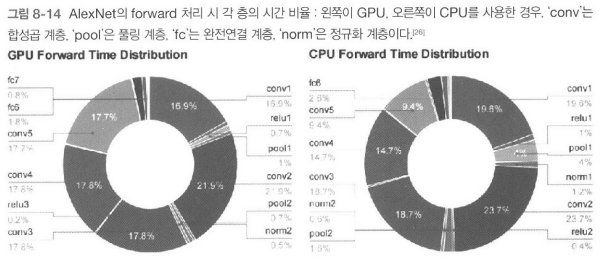   
- 그림은 AlexNet의 forward 처리(순전파)에서 각 층이 소비하는 시간을 원 그래프로 보여줌   
- 그림에서 보듯 AlexNet에서는 오랜 시간을 합성곱 계층에서 소요함   
- 실제로 합성곱 계층의 처리 시간을 다 더하면 GPU에서는 전체의 95%, CPU에서는 전체의 89%까지 달함   
- 그래서 합성곱 계층에서 이뤄지는 연산을 어떻게 고속으로 효율적으로 하느냐가 딥러닝의 과제   
- 그림은 추론 때의 결과지만, 학습 시에도 마찬가지로 합성곱 계층에서 많은 시간을 소비하게 됨   

> 합성곱 계층에서 수행하는 연산은 "7.2 합성곱 계층"에서 설명했듯이, 결국 '단일 곱셈-누산'   
> 그래서 딥러닝 고속화라는 주제는 대량의 '단일 곱셈-누산'을 어떻게 고속으로 효율적으로 계산하느냐는 것

### GPU를 활용한 고속화

GPU는 원래 그래픽 전용 보드에 이용해왔음   
그러나 최근에는 그래픽 처리뿐 아니라 범용 수치 연산에도 이용함   
GPU는 병렬 수치 연산을 고속으로 처리할 수 있으니, 그 압도적인 힘을 다양한 용도로 활용하자는 것이 **GPU 컴퓨팅** 의 목적   
이처럼 GPU로 범용 수치 연산을 수행하는 것을 GPU 컴퓨팅이라고 함   

딥러닝에서는 대량의 단일 곱셈-누산(또는 큰 행렬의 곱)을 수행해야 함   
이러한 대량 병렬 연산은 GPU의 특기(반대로 CPU는 연속적인 복잡한 계산을 잘 처리함)   
그래서 딥러닝 연산에서는 GPU를 이용하면 CPU만 쓸 때보다 놀라울 정도록 빠르게 결과를 얻을 수 있음   
그렇다면 과연 GPU로 어느 정도까지 빨라지는지 예를 보면   
- 아래 그림은 AlexNet의 학습 시간을 CPU와 GPU에서 비교한 결과   
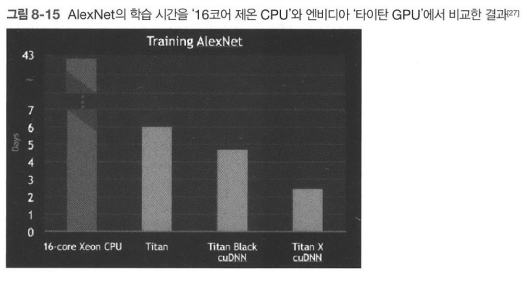   
- 그림과 같이 CPU에서는 40여 일이나 걸리지만 GPU로는 6일까지 단축됨   
- 또, cuDNN이라는 딥러닝에 최적화된 라이브러리를 이용하면 더욱 빨라짐을 확인할 수 있음   

GPU는 주로 엔비디아와 AMD, 두 회사가 제공함   
두 회사의 GPU 모두 범용 수치 연산에 이용할 수는 있지만, 딥러닝과 더 '친한' 쪽은 엔비디아   
실제로 대부분의 딥러닝 프레임워크는 엔비디아 GPU에서만 혜택을 받을 수 있음   
엔비디아의 GPU 컴퓨팅용 통합 개발 환경인 **CUDA** 를 사용하기 때문   
위 그림에서 등장하는 **cuDNN** 은 CUDA 위에서 동작하는 라이브러리로, 딥러닝에 최적화된 함수 등이 구현되어 있음   

> 합성곱 계층에서 행하는 연산을 im2col을 이용해 큰 행렬의 곱으로 변환할 수 있었음   
> 이러한 im2col의 방식은 GPU로 구현하기에도 적합함   
> GPU는 '작은' 단위로 계산하기보다는 큰 덩어리를 한 번에 계산하는 데 유리하기 때문   
> 즉, im2col로 거대한 행렬의 곱으로 한 번에 계산하여 GPU의 잠재력을 끌어내는 것

### 분산 학습

GPU로 딥러닝 연산을 꽤 가속할 수 있지만, 그래도 심층 신경망에서는 학습에 며칠 혹은 몇 주가 걸리기도 함   
그리고 지금까지 살펴본 것처럼 딥러닝은 많은 시행착오를 동반함   
뛰어난 신경망을 만들려면 시험을 수없이 반복해야 하고, 그려려면 1회 학습에 걸리는 시간을 최대한 단축하고 싶다는 욕구가 필연적으로 생겨남   
그래서 딥러닝 학습을 수평 확장(scale out)하자는 아이디어(즉, '분산 학습')가 중요해지는 것   

딥러닝 계산을 더욱 고속화하고자 다수의 GPU와 기기로 계산을 분산하기도 함   
최근에는 다수의 GPU와 컴퓨터를 이용한 분산 학습을 지원한 딥러닝 프레임워크들이 나타나고 있음   
그중에서도 구글의 텐서플로와 마이크로소프트의 CNTK(computational Network Toolkit)는 분산 학습에 역점을 두고 개발하고 있음   
거대한 데이터센터의 저지연, 고처리량(low latency, high throughput) 네트워크 위에서 이 프레임워크들이 수행하는 분산 학습은 놀라운 효과를 보이고 있음   

분산 학습까지 더하면 어느 수준까지 고속화할 수 있는지   
아래 그림은 텐서플로로 알아본 분산 학습의 효과   
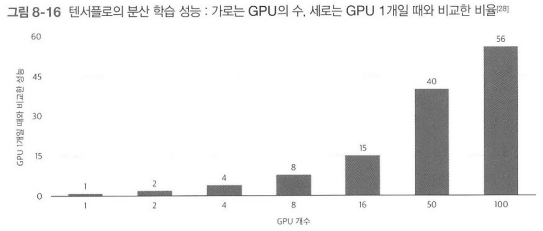   
- 그림에서 보듯 GPU 수가 늘어남에 따라 학습도 빨라짐   
- 실제로 여러 기기를 연결하여 GPU를 100까지 사용하니 하나일 때보다 56배가 빨라짐   
- 7일 짜리 작업을 불과 3시간 만에 끝낸다는 것으로, 분산 학습의 놀라운 효과를 증명하고 있음   

분산 학습에서도 '계산을 어떻게 분산시키느냐'는 몹시 어려운 문제   
컴퓨터 사이의 통신과 데이터 동기화 등, 쉽게 해결할 수 없는 문제를 얼마든지 끌어안고 있음   
그래서 이런 어려운 문제는 텐서플로 같은 뛰어난 프레임워크에 맡기는 것이 좋음   
여기에서는 분산 학습의 상세 내용은 다루지 않음   
분산 학습 관련 기술적인 내용은 텐서플로 기술 논문 등을 참고

### 연산 정밀도와 비트 줄이기

계산 능력 외에도 메모리 용량과 버스 대역폭 등이 딥러닝 고속화에 병목이 될 수 있음   
- 메모리 용량 면에서는 대량의 가중치 매개변수와 중간 데이터를 메모리에 저장해야 한다는 것을 생각해야 함   
- 버스 대역폭 면에서는 GPU(혹은 CPU)의 버스를 흐르는 데이터가 많아져 한계를 넘어서면 병목이 됨   

이러한 경우를 고려하면 네트워크로 주고받는 데이터의 비트 수는 최소로 만드는 것이 바람직함   

컴퓨터에서는 주로 64비트나 32비트 부동소수점 수를 사용해 실수를 표현함   
많은 비트를 사용할수록 계산 오차는 줄어들지만, 그만큼 계산에 드는 비용과 메모리 사용량이 늘고 버스 대역폭에 부담을 줌   

다행히 딥러닝은 높은 수치 정밀도(수치를 몇 비트로 표현하느냐)를 요구하지 않음   
이는 신경망의 중요한 성질 중 하나로, 신경망의 견고성에 따른 특성   
- 예를 들어 신경망은 입력 이미지에 노이즈가 조금 섞여 있어도 출력 결과가 잘 달라지지 않는 강건함을 보여줌   

이런 견고성 덕분에 신경망을 흐르는 데이터를 '퇴화'시켜도 출력에 주는 영향은 적음   

컴퓨터에서 실수를 표현하는 방식으로 **32비트 단정밀도(single-precision)** 와 **64비트 배정밀도(double-precision)** 부동소수점 등의 포맷이 있지만,   
지금까지의 실험으로는 딥러닝은 **16비트 반정밀도(half-precision)** 만 사용해도 학습에 문제가 없다고 알려져 있음   
실제로 엔비디아의 2016년 GPU인 **파스칼(Pascal)** 아키텍처는 이 포맷을 지원하여, 이제는 반정밀도 부동소수점이 표준적으로 이용되리라 봄   

> 엔비디아의 맥스웰(Maxwell) 세대 GPU는 반정밀도 부동소수점 수를 스토리지(데이터를 저장하는 기능)로 지원하고 있었지만, 연산 자체는 16비트로 수행하지 않았음   
> 이것이 파스칼 세대에 와서 연산 역시 16비트로 하기 시작하여, 이전 세대보다 2배 정도 빨라짐   

이 책은 지금까지 딥러닝을 구현하며 수치 정밀도에는 특별히 주의하지 않았음, 몇 가지 짚어보면   
파이썬에서는 일반적으로 64비트 배정밀도 부동소수점 수를 사용함   
하지만 넘파이는 16비트 반정밀도 부동소수점도 지원하며, 이를 사용해도 정확도가 떨어지지 않는 것을 쉽게 확인할 수 있음   
(단, 스토리지로서 16비트라는 틀이 있을 뿐 연산 자체는 16비트로 수행하지 않음)   
- 아래 코드 참고   

딥러닝의 비트 수를 줄이는 연구가 몇 가지 진행되고 있음   
가중치와 중간 데이터를 1비트로 표현하는 <Binarize Neural Networks>라는 방법도 등장했음   
딥러닝을 고속화하기 위해 비트를 줄이는 기술은 앞으로 주시해야 할 분야이며, 특히 딥러닝을 임베디드용으로 이용할 때 중요한 주제

In [15]:
import sys, os
sys.path.append(os.path.join(os.path.pardir))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

network = DeepConvNet()
network.load_params("deep_convnet_params.pkl")

sampled = 10000 # 고속화를 위한 표본추출
x_test = x_test[:sampled]
t_test = t_test[:sampled]

print("caluculate accuracy (float64) ... ")
print(network.accuracy(x_test, t_test))

# float16(반정밀도)로 형변환
x_test = x_test.astype(np.float16)
for param in network.params.values():
    param[...] = param.astype(np.float16)

print("caluculate accuracy (float16) ... ")
print(network.accuracy(x_test, t_test))

caluculate accuracy (float64) ... 
0.9935
caluculate accuracy (float16) ... 
0.9935


## 딥러닝의 활용

지금까지 딥러닝을 활용한 예를 손글씨 숫자 인식이라는 이미지 분류를 중심으로 살펴봤음 - 이는 '사물 인식'의 한 분야   
그러나 딥러닝은 사물 인식뿐 아니라 온갖 문제에 적용할 수 있음   
이미지, 음성, 자연어 등 수많은 분야에서 딥러닝은 뛰어난 성능을 발휘함   
이번 절에서는 딥러닝이 할 수 있는 것을 컴퓨터 비전 분야를 중심으로 몇 가지 소개함

### 사물 검출

사물 검출은 아래 그림과 같이 이미지 속에 담긴 사물의 위치와 종류(클래스)를 알아내는 기술   
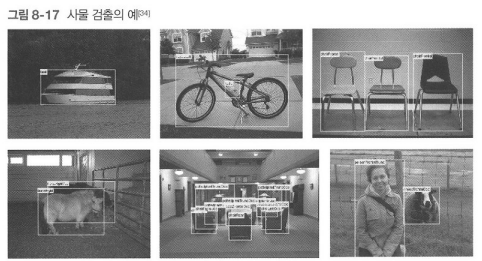   
- 이 그림에서 보듯 사물 검출은 사물 인식보다 어려운 문제   
- 지금까지 본 사물 인식은 이미지 전체를 대상으로 했는데, 사물 검출에서는 이미지 어딘가에 있을 사물의 위치까지 알아내야 함   
- 게다가 한 이미지에 여러 사물이 존재할 수도 있음   

이런 사물 검출 문제에 CNN을 기반으로 한 기법이 몇 가지 제안되었음   
이 기법들이 발군의 성능을 보여 사물 검출에도 딥러닝이 효과적임을 시사하고 있음   

CNN을 이용하여 사물 검출을 수행하는 방식은 몇 가지가 있는데, 그중에서도 **R-CNN(Rerions with Convolutional Neural Network)** 이 유명함   
아래 그림은 R-CNN의 처리 흐름   
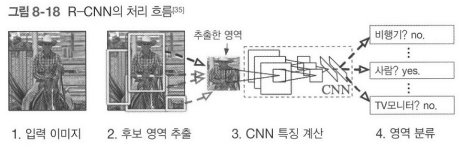   
- R-CNN 그림에서 주목할 곳은 '2. 후보 영역 추출'과 '3. CNN 특징 계산'   
- 먼저 사물이 위치한 영역을 (어떤 방법으로) 찾아내고, 추출한 각 영역에 CNN을 적용하여 클래스를 분류하는 것   
- 여기서 이미지를 사각형으로 변형하거나 분류할 때 서포트 벡터 머신(SVM)을 사용하는 등 실제 처리 흐름은 다소 복잡하지만,   
- 큰 틀에서는 이 두 가지 처리(후보 영역 추출과 CNN 특징 계산)로 구성됨   

후보 영역 추출(사물처럼 보이는 물체를 찾아 처리)에는 컴퓨터 비전 분야에서 발전해온 다양한 기법을 사용할 수 있고, R-CNN 논문에서는 Selective Search 기법을 사용했음   
이 후보 영역 추출까지 CNN으로 처리하는 **Faster R-CNN** 기법도 등장함   
Faster R-CNN은 모든 일을 하나의 CNN에서 처리하기 때문에 아주 빠름

### 분할

**분할(Segmentation)** 이란 이미지를 픽셀 수준에서 분류하는 문제   
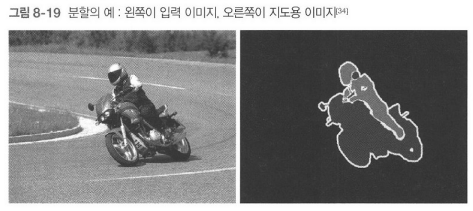   
- 그림과 같이 픽셀 단위로 객체마다 채색된 지도(supervised) 데이터를 사용해 학습함   
- 그리고 추론할 때 입력 이미지의 모든 픽셀을 분류함   

지금까지 구현한 신경망은 분류를 이미지 전체를 대상으로 해왔음   
이를 픽셀 수준에 적용하는 방법은?   

신경망을 이용해 분할하는 가장 단순한 방법은 모든 픽셀 각각을 추론하는 것   
- 예를 들어 어떤 직사각형 영역의 중심 픽셀의 클래스를 분류하는 신경망을 만들어서, 모든 픽셀을 대상으로 하나씩 추론 작업을 실행함   
- 이런 식으로는 픽셀 수만큼 forward 처리를 해야 하여 긴 시간이 걸리게 됨(정확히는 합성곱 연산에서 많은 영역을 쓸데없이 다시 계산하는 것이 문제가 됨)   
- 이러한 낭비를 줄여주는 기법으로 FCN(Fully Convolutional Network)이 고안됨   
    - 이는 단 한 번의 forward 처리로 모든 픽셀의 클래스를 분류해주는 기법   

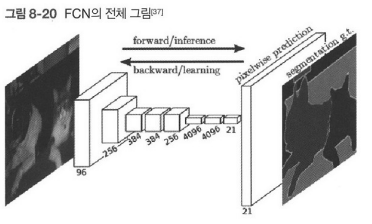   
- 위 그림은 FCN을 나타냄   
- Fully Convolutional Network를 직역하면 '합성곱 계층만으로 구성된 네트워크'가 됨   
- 일반적인 CNN이 완전연결 계층을 이용하는 반면, FCN은 이 완전연결 계층을 '같은 기능을 하는 합성곱 계층'으로 바꿈   
- 사물 인식에서 사용한 신경망의 완전연결 계층에서는 중간 데이터의 공간 볼륨(다차원 형태)을 1차원으로 변환하여 한 줄로 늘어선 노드들이 처리했으나,   
- FCN에서는 공간 볼륨을 유지한 채 마지막 출력까지 처리할 수 있음   
- FCN은 그림에서 보듯 마지막에 공간 크기를 확대하는 터리를 도입했다는 것도 특징   
- 이 확대 처리로 인해 줄어든 중간 데이터를 입력 이미지와 같은 크기까지 단번에 확대할 수 있음   
- FCN의 마지막에 수행하는 확대는 이중 선형 보간(bilinear interpolation)에 의한 선형 확대   
- FCN에서는 이 선형 확대를 역합성곱(deconvolution) 연산으로 구현해내고 있음 (자세한 내용은 FCN 논문을 참고)   

> 완전연결 계층에서는 출력이 모든 입력과 연결됨   
> 이와 같은 구성을 합성곱 계층으로도 구현할 수 있음   
> 가령 입력 크기가 32 X 10 X 10(채널 32개, 높이 10, 너비 10)인 데이터에 대한 완전연결 계층은 필터 크기가 32 X 10 X 10인 합성곱 계층으로 대체할 수 있음   
> 만약, 완전연결 계층의 출력 노드가 100개라면 함성곱 계층에서는 기존의 32 X 10 X 10 필터를 100개 준비하면 완전히 같은 처리를 할 수 있음   
> 이처럼 완전연결 계층은 같은 일을 수행하는 합성곱 계층으로 대체할 수 있음

### 사진 캡션 생성

컴퓨터 비전과 자연어를 융합한 재미있는 연구가 있음   
아래 그림과 같은 사진을 주면, 그 사진을 설명하는 글(사진 캡션)을 자동으로 생성하는 연구   
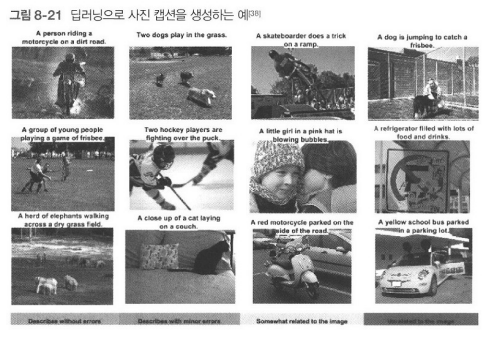   
- 예를 들어 위 그림의 첫 번째는 사진만 보고 "비포장도로에서 오토바이를 타는 사람(A person riding a motorcycle on a dirt road)"이라는 문장으로 자동으로 생성했음   
- 설명과 사진이 정확히 일치함   
- 오토바이를 타고 있다는 것뿐만이 아니고 거친 비포장도로라는 것도 '이해'한 것이 놀라움   

딥러닝으로 사진 캡션을 생성하는 방법으로는 NIC(Neural Image Caption) 모델이 대표적   
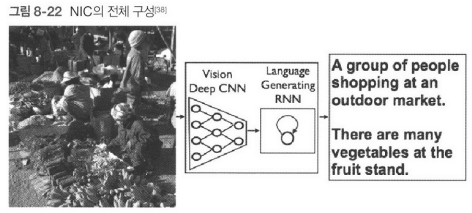   
- NIC는 위 그림과 같이 심층 CNN과 자연어를 다루는 **순환 신경망(Recurrent Neural Network, RNN)** 으로 구성됨   
    - RNN은 순환적 관계를 갖는 신경망으로 자연어나 시계열 데이터 등의 연속된 데이터를 다룰 때 많이 활용함   
- NIC는 CNN으로 사진에서 특징을 추출하고, 그 특징을 RNN에 넘김   
- RNN은 CNN이 추출한 특징을 초깃값으로 해서 텍스트를 '순환적'으로 생성함   
- 이 책에서는 더 이상의 상세 기술은 않지만, 기본적으로 NIC는 2개의 신경망(CNN과 RNN)을 조합한 간단한 구성   
- 그래서 놀라울 정도로 정확한 사진 캡션을 만들어내는 것   
- 또한, 사진이나 자연어와 같은 여러 종류의 정보를 조합하고 처리하는 것을 **멀티모달 처리(multimodal processing)** 라고 함 - 주목받는 분야 중 하나   

> RNN의 R은 Recurrent(순환적)를 뜻함   
> 여기에서 순환은 신경망의 순환적 네트워크 구조를 말함   
> 이 순환적인 구조로 인해 이전에 생성한 정보에 영향을 받는(바꾸어 말하면, 과거의 정보를 기억하는) 점이 RNN의 특징   
> 예를 들어 '나'라는 단어를 생성한 뒤 '잤다'라는 단어를 생성하면   
> 먼저 만든 '나'의 영향을 받아 '는'이라는 조사가 자동으로 생성되어, 최종적으로 '나는 잤다'라는 문장이 완성되는 식   
> 이처럼 자연어와 시계열 데이터 등 연속성이 있는 데이터를 다룰 때 RNN은 과거의 정보를 기억하면서 동작함

## 딥러닝의 미래

딥러닝은 앞에서 언급한 분야 외에도 여런 분야에서 이용되어 왔음   
이번 절에서는 딥러닝의 가능성과 미래를 느낄 만한 연구를 몇 가지 소개함

### 이미지 스타일(화풍) 변환

답러닝을 할용해 화가처럼 '그림을 그리는' 연구가 있음   
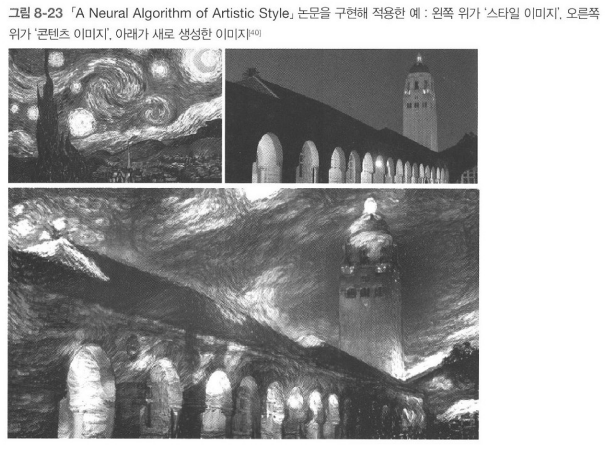   
- 위 그림은 두 이미지를 입력해서 새로운 그림을 생성하는 연구   
- 하나는 '콘텐츠 이미지', 다른 하나는 '스타일 이미지'라 부르는데, 이 둘을 조합해 새로운 그림을 그려줌   
- 그림과 같이 고흐의 화풍을 콘텐츠 이미지에 적용하도록 지정하면, 이를 기초로 딥러닝이 새로운 그림을 그림   
- 이 기법을 담은 <A Neural Algorithm of Artistic Style> 논문은 발표되자마자 전 세계에서 많은 이목을 끌었음   

이 책에서는 이 연수를 자세히 설명하지는 않음   
큰 틀만 얘기하면, 이 기술은 네트워크의 중간 데이터가 콘텐츠 이미지의 중간 데이터와 비슷해지도록 학습함   
이렇게 하면 입력 이미지가 콘텐츠 이미지의 형태를 흉내 낼 수 있음   
또, 스타일 이미지의 화풍을 흡수하기 위해 '스타일 행렬'이라는 개념을 도입함   
그 스타일 행렬의 오차를 줄이도록 학습하여 입력 이미지를 고흐의 화풍과 비슷해지게 만들 수 있는 것

### 이미지 생성

앞의 이미지 스타일 변환 예는 새로운 그림을 생성하려면 이미지 두 장을 입력해야 했음   
한편 아무런 입력 이미지 없이도 새로운 이미지를 그려내는 연구도 진행 중   
물론 먼저 대량의 이미지를 사용하여 학습하긴 하지만, 학습이 끝난 후에는 아무런 입력 이미지 없이도 새로운 그림을 그려냄   
가령 딥러닝으로 '침실' 이미지를 무로부터 생성하는 게 가능   
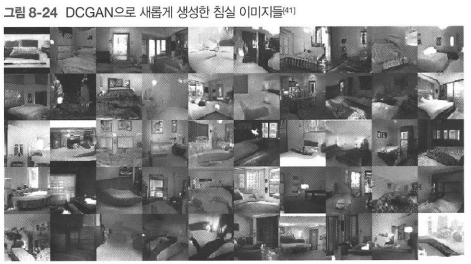   
- 위 그림의 이미지는 **DCGAN(Deep Convolutional Generative Adversarial Network)** 기법으로 생성한 침실 이미지들   
- 그림의 이미지들은 진짜 사진처럼 보일지 모르지만, 모두 DCGAN을 사용해 새롭게 생성한 이미지
- 즉, DCGAN이 그린, 아직 아무도 본 적 없는 이미지(학습 데이터에는 존재하지 않는 이미지)이며, 처음부터 새로 생성한 이미지   

진짜와 구분할 수 없는 수준의 이미지를 그리는 DCGAN은 이미지를 생성하는 과정을 모델화함   
그 모델을 대량의 이미지(가령 침실이 찍힌 대량의 이미지)를 사용해 학습하고, 학습이 끝나면 그 모델을 이용하여 새로운 그림을 생성할 수 있음   

DCGAN도 딥러닝을 사용함   
DCGAN 기술의 핵심은 생성자(Generator)와 식별자(Discriminator)로 불리는 2개의 신경망을 이용한다는 점   
생성자가 진짜와 똑같은 이미지를 생성하고 식별자는 그것이 진짜인지(생성자가 생성한 이미지인지, 아니면 실제로 촬영된 이미지인지)를 판정함   
그렇게 해서 둘을 겨루도록 학습시켜, 생성자는 더 정교한 가짜 이미지 생성 기술을 학습하고 식별자는 더 정확하게 간파할 수 있는 감정사로 성장하는 것   
이렇게 둘의 능력을 부지런히 갈고닦게 한다는 개념이 **GAN(Generative Adversarial Network)** 기술의 재미난 점   
그렇게 절차탁마해서 성장한 생성자는 최종적으로는 진짜와 착각할 정도의 이미지를 그려내는 능력을 기르는 것   

> 이전까지 살펴본 기계학습 문제는 **지도 학습(supervised learning)** 이라는 유형의 문제였음   
> 지도 학습은 손글씨 숫자 인식처럼 이미지 데이터와 정답 레이블을 짝지은 데이터셋을 이용함   
> 그러나 이번 절에서 거론한 문제는 지도용 데이터는 주어지지 않고, 단지 대량의 이미지(이미지의 집합)만 주어짐   
> 즉, 지도 없이 스스로 학습하는 **자율 학습(unsupervised learning)** 문제   
> 자율 학습은 비교적 오래전부터 연구된 분야지만(Deep Belief Network와 Deep Boltzmann Machine이 대표적) 최근에는 그다지 활발하게 연구되지는 않는다는 느낌   
> 최근 딥러닝을 사용한 DCGAN 등과 같은 기법이 시선을 끌면서, 앞으로 자율 학습도 새로운 도약을 기대할 수 있을지도 모름

### 자율 주행

사람 대신 컴퓨터가 자동차를 운전하는 **자율 주행** 기술이 눈앞으로 다가왔음   
자동차 제조 업체뿐 아니라 IT기업과 대학, 연구소 등도 자율 주행 상용화 경쟁에 뛰어들었음   
자율 주행은 다양한 기술(주행 경로를 정하는 경로 계획(path plan) 기술과 카메라나 레이저 등의 탐사 기술 등)을 모아 구현하고 있지만,   
그중에서도 주위 환경을 올바르게 인식하는 기술이 가장 중요한 문제라고 함   
시시각각 변하는 환경과 종횡무진 오가는 다른 차와 사람들을 올바르게 인식하기가 매우 까다롭기 때문   

다양한 환경에서도 안전한 주행 영역을 올바로 인식하게 되면 자율 주행의 실현도 멀지 않음   
그리고 최근에는 그런 주위 환경을 인식하는 기술에서 딥러닝이 큰 역할을 해줄 것으로 기대하고 있음   
- 예를 들어 **SegNet** 이라는 CNN 기반 신경망은 아래 그림과 같이 주변 환경을 정확하게 인식해냄   
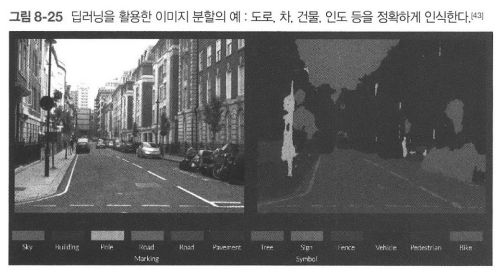   
- 그림과 같이 입력 이미지를 분할(픽셀 수준에서 판정)하고 있음   
- 결과를 보면 도로와 건물, 보도와 나무, 차량과 오토바이 등을 어느 정도 정확히 판별하고 있음   
- 이런 인식 기술이 딥러닝에 힘입어 향후 한층 정확해지고 빨라지면 자율 주행이 현실이 될 것

### Deep Q-Network(강화학습)

(자전거를 배울 때처럼) 사람이 시행착오를 겪으며 배우듯 컴퓨터도 시행착오 과정에서 스스로 학습하게 하려는 분야가 있음   
이는 '가르침'에 의존하는 '지도 학습'과는 다른 분야로, **강화학습(reinforcement learning)** 이라 함   

강화학습에서는 에이전트라는 것이 환경에 맞게 행동을 선택하고, 그 행동에 의해서 환경이 변한다는 게 기본적인 틀   
환경이 변화하면 에이전트는 어떠한 보상을 얻음   
강화학습의 목적은 더 나은 보상을 받는 쪽으로 에이전트의 행동 지침을 바로잡는 것   
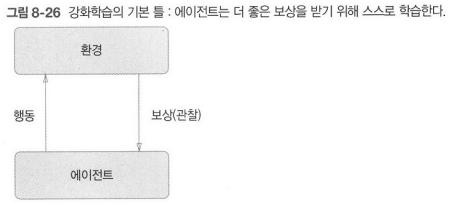   
- 그림은 강화학습의 기본 틀   
- 여기에서 주의점은 보상은 정해진 것이 아니라 '예상 보상'이라는 점   
- 예를 들면 <슈퍼 마리오 브라더스>에서 마리오를 오르쪽으로 이동했을 때 얻는 보상이 항상 명확한 것이 아님   
- 어떤 상황에서 이동한 것이냐에 따라 보상은 천차만별이 될 수 있음   
- 이런 불명확한 상황에서는 게임 점수(동전을 먹거나 적을 쓰러뜨리는 등)나 게임 종료 등의 명확한 지표로부터 역산해서 '예상 보상'을 정해야 함   
- 만약 지도 학습이었다면 행동에 대한 '지도'를 통해 올바른 평가를 받을 수 있었을 것   

딥러닝을 사용한 강화학습 중 **Deep Q-Network** (일명 DQN)라는 방법이 있음   
이는 Q학습이라는 강화학습 알고리즘을 기초로 함   
Q학습에서는 최적 행동 가치 함수로 최적인 행동을 정함   
이 함수를 딥러닝(CNN)으로 비슷하게 흉내내어 사용하는 것이 DQN   

DQN 연구 중에는 비디오 게임을 자율 학습시켜 사람을 뛰어넘는 수준의 조작을 실현한 사례가 보고되고 있음   
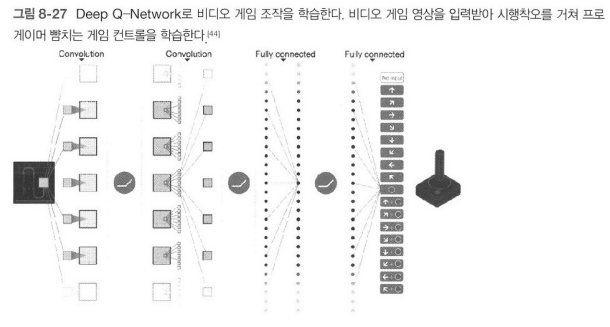   
- 그림과 같이 DQN에서 사용하는 CNN은 게임 영상 프레임(4개의 연속한 프레임)을 입력하여   
- 최종적으로는 게임을 제어하는 움직임(조이스틱 이동량이나 버튼 조작 여부)에 대하여 각 동작의 '가치'를 출력함   
- 그동안의 비디오 게임 학습에서는 게임의 상태(캐릭터 위치 등)는 미리 추출하는 것이 보통이었음   
- 그러나 DQN에서는 그림과 같이 입력 데이터는 비디오 게임의 영상뿐   
- 이는 DQN의 주목할 점으로, DQN의 응용 가능성을 현격히 높였다고 할 수 있음   
- 게임마다 설정을 바꿀 필요없이 단순히 DQN에 게임 영상을 보여주기만 하면 되기 때문   
- 실제 DQN은 구성을 변경하지 않고도 팩맨과 아타리 같은 많은 게임을 학습할 수 있으며, 수많은 게임에서 사람보다 뛰어난 성적을 거두고 있음   

> 2016년에는 인공지능인 알파고가 바둑 챔피언 이세돌을 꺾었다는 소식이 화제였음   
> 이 알파고에도 딥러닝과 강화학습이 이용됨   
> 알파고는 3,000만 개의 프로 기보를 보며 학습한 후, 알파고 스스로 자신과 맞붙는 대결을 반복하면서 수련했음   
> 또한, 알파고와 DQN은 모두 구글이 인수한 딥마인드(DeepMind)가 진행한 연구

## 정리

이번 장에서는 (약간) 깊은 CNN을 구현하고, 손글씨 숫자 인식에서 99%를 넘는 높은 정확도를 얻었음   
또, 네트워크를 깊게 하는 동기를 이야기하고 딥러닝이 더 깊어지는 방향으로 가고 있다는 것도 설명함   
그리고 딥러닝의 트렌드와 실제 활용 예, 고속화를 위한 연구와 미래를 느끼게 해주는 연구 사례를 소개함   

### 이번 장에서 배운 내용

- 수많은 문제에서 신경망을 더 깊게 하여 성능을 개선할 수 있음
- 이미지 인식 기술 대회인 ILSVRC에서는 최근 딥러닝 기반 기법이 상위권을 독점하고 있으며, 그 깊이도 더 깊어지는 추세
- 유명한 신경망으로는 VGG, GoooLeNet, ResNet이 있음
- GPU와 분산 학습, 비트 정밀도 감소 등으로 딥러닝을 고속화할 수 있음
- 딥러닝(신경망)은 사물 인식뿐 아니라 사물 검출과 분할에도 이용할 수 있음
- 딥러닝의 응용 분야로는 사진의 캡션 생성, 이미지 생성, 강화학습 등이 있음, 자율주행에도 딥러닝을 접목하고 있어 기대됨